### Let's read data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
!pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable


In [12]:
train_data=pd.read_excel(r'C:/Users/Amsha/Desktop/Flight-Fare-Prediction/Data_Train.xlsx')

In [13]:
type(train_data)

pandas.core.frame.DataFrame

In [14]:
train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [15]:
train_data.shape

(10683, 11)

### doing data cleaning--

In [16]:
train_data.isnull().sum()


Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [17]:
train_data[train_data["Total_Stops"].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [18]:
train_data=train_data.dropna()

In [19]:
train_data.isnull().sum()


Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [20]:
train_data[train_data.duplicated(keep=False)].sort_values(by=train_data.columns.tolist())


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
6321,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
9848,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
572,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
8168,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
1495,Air India,1/04/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,01:20 02 Apr,15h 20m,2 stops,No info,10408
...,...,...,...,...,...,...,...,...,...,...,...
2870,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,05:45,08:35,2h 50m,non-stop,No check-in baggage included,4273
1535,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,20:30,23:20,2h 50m,non-stop,No check-in baggage included,3873
3711,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,20:30,23:20,2h 50m,non-stop,No check-in baggage included,3873
2634,Vistara,24/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,5403


In [21]:
train_data=train_data.drop_duplicates()

In [22]:
train_data[train_data.duplicated(keep=False)].sort_values(by = train_data.columns.tolist())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [23]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10462 non-null  object
 1   Date_of_Journey  10462 non-null  object
 2   Source           10462 non-null  object
 3   Destination      10462 non-null  object
 4   Route            10462 non-null  object
 5   Dep_Time         10462 non-null  object
 6   Arrival_Time     10462 non-null  object
 7   Duration         10462 non-null  object
 8   Total_Stops      10462 non-null  object
 9   Additional_Info  10462 non-null  object
 10  Price            10462 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 980.8+ KB


### "Date Feature Engineering : Extract Day, Month & Year"

In [24]:
data=train_data.copy()

In [25]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [26]:
data.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [27]:
data['Date_of_Journey']

0        24/03/2019
1         1/05/2019
2         9/06/2019
3        12/05/2019
4        01/03/2019
            ...    
10678     9/04/2019
10679    27/04/2019
10680    27/04/2019
10681    01/03/2019
10682     9/05/2019
Name: Date_of_Journey, Length: 10462, dtype: object

In [28]:
data['Date_of_Journey']=pd.to_datetime(data['Date_of_Journey'],format="%d/%m/%Y")

In [29]:
data['Date_of_Journey'].dtype

dtype('<M8[ns]')

In [30]:
data["Journey_day"]=data['Date_of_Journey'].dt.day
data["Journey_month"]=data['Date_of_Journey'].dt.month
data["Journey_year"]=data['Date_of_Journey'].dt.year

In [31]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019


In [32]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

In [33]:
data["Arrival_Time_hour"]=pd.to_datetime(data["Arrival_Time"]).dt.hour
data["Arrival_Time_minute"]=pd.to_datetime(data["Arrival_Time"]).dt.minute

In [34]:
data["Dep_Time_hour"]=pd.to_datetime(data["Dep_Time"]).dt.hour
data["Dep_Time_minute"]=pd.to_datetime(data["Dep_Time"]).dt.minute

In [35]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50


### Let's analyse when will most of the flights take-off..


In [36]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,4,25,9,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,23,30,18,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,21,35,16,50


In [37]:
def flight_dep_time(x):
    if(x>4) and (x<=8):
        return "Early Morning"
    elif(x>8) and (x<=12):
        return "Morning"
    elif(x>12) and (x<=16):
        return "Noon"
    if(x>16) and (x<=20):
        return "Evening"
    elif(x>20) and (x<=24):
        return "Night"
    else:
        return "Late Night"
        
        

In [38]:
data["Dep_Time_hour"].apply(flight_dep_time)

0                Night
1        Early Morning
2              Morning
3              Evening
4                 Noon
             ...      
10678          Evening
10679          Evening
10680    Early Morning
10681          Morning
10682          Morning
Name: Dep_Time_hour, Length: 10462, dtype: object

In [39]:
data["Dep_Time_hour"].apply(flight_dep_time).value_counts()

Dep_Time_hour
Early Morning    2814
Evening          2323
Morning          2170
Noon             1696
Night             995
Late Night        464
Name: count, dtype: int64

<Axes: xlabel='Dep_Time_hour'>

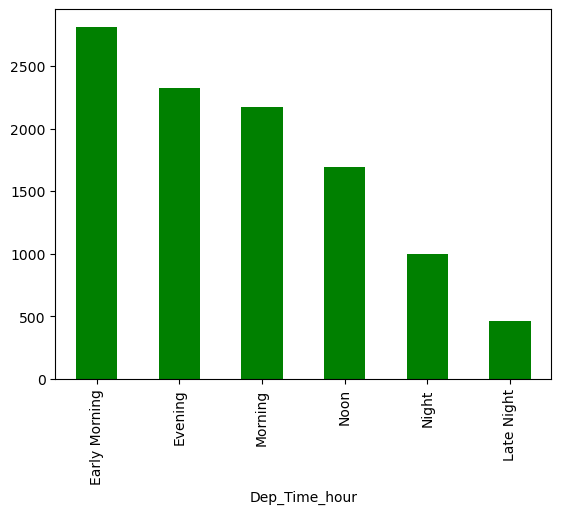

In [40]:
data["Dep_Time_hour"].apply(flight_dep_time).value_counts().plot(kind="bar",color="g")

In [41]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable


In [42]:
import plotly.express as px

In [43]:
counts=data["Dep_Time_hour"].apply(flight_dep_time).value_counts().reset_index()
counts.columns=["Dep_shift","total_flights"]

In [44]:
counts

,Dep_shift,total_flights
0,Early Morning,2814
1,Evening,2323
2,Morning,2170
3,Noon,1696
4,Night,995
5,Late Night,464


In [45]:
px.bar(data_frame=counts,x="Dep_shift",y="total_flights",color_discrete_sequence=["green"])

### Data Pre-Processing on "Duration"

In [46]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,4,25,9,25


In [47]:
def preprocess_duration(x):
    if "h" not in x:
        x='0h'+''+x
    elif "m" not in x:
        x = x+''+'0m'
    return x

In [48]:
data['Duration']=data["Duration"].apply(preprocess_duration)

In [49]:


data['Duration']

0        2h 50m
1        7h 25m
2         19h0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680      3h0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10462, dtype: object

In [50]:
data["Duration_hour"]=pd.to_timedelta(data["Duration"]).dt.components.hours

In [51]:
data["Duration_minute"]=pd.to_timedelta(data["Duration"]).dt.components.minutes

In [52]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute,Duration_hour,Duration_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50,7,25
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h0m,2 stops,No info,13882,9,6,2019,4,25,9,25,19,0


In [53]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year', 'Arrival_Time_hour', 'Arrival_Time_minute',
       'Dep_Time_hour', 'Dep_Time_minute', 'Duration_hour', 'Duration_minute'],
      dtype='object')

In [54]:
cols_to_drop=['Dep_Time','Arrival_Time','Duration','Date_of_Journey']
data.drop(cols_to_drop,axis=1,inplace=True)

In [55]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year', 'Arrival_Time_hour', 'Arrival_Time_minute',
       'Dep_Time_hour', 'Dep_Time_minute', 'Duration_hour', 'Duration_minute'],
      dtype='object')

### Analyse whether Duration impacts Price or not?


In [56]:
data.dtypes

Airline                object
Source                 object
Destination            object
Route                  object
Total_Stops            object
Additional_Info        object
Price                   int64
Journey_day             int32
Journey_month           int32
Journey_year            int32
Arrival_Time_hour       int32
Arrival_Time_minute     int32
Dep_Time_hour           int32
Dep_Time_minute         int32
Duration_hour           int64
Duration_minute         int64
dtype: object

In [57]:
data["Duration_total_mins"]=data["Duration_hour"]*60+data["Duration_minute"]

In [58]:
data.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute,Duration_hour,Duration_minute,Duration_total_mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,1,10,22,20,2,50,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,13,15,5,50,7,25,445


<Axes: xlabel='Duration_total_mins', ylabel='Price'>

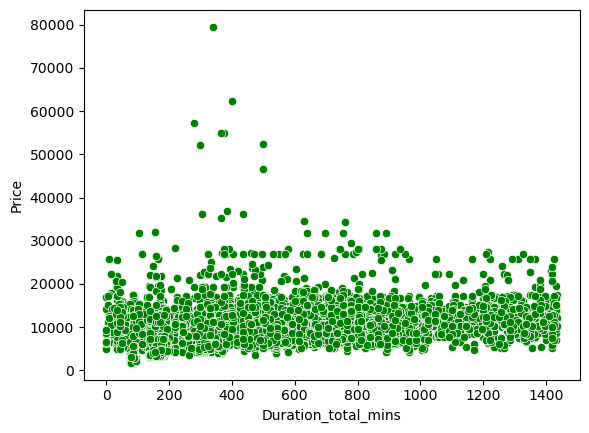

In [59]:
sns.scatterplot(data=data,x="Duration_total_mins",y="Price" ,color="green")

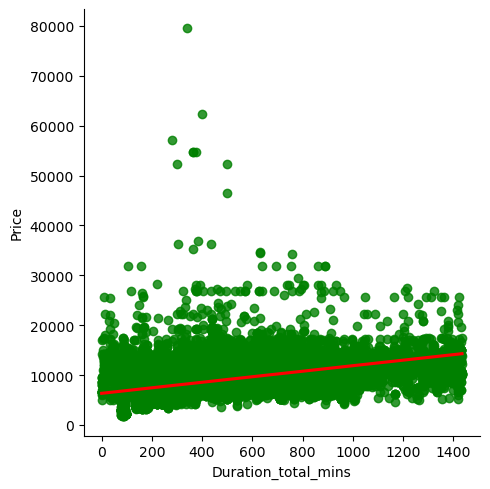

In [79]:
 sns.lmplot(data=data,x="Duration_total_mins",y="Price",scatter_kws={"color": "green"},line_kws={"color":"red"})

In [61]:
import numpy as np

In [62]:
m,c=np.polyfit(data["Duration_total_mins"],data["Price"],1)

In [63]:
m

np.float64(5.535752729771948)

In [64]:
c

np.float64(6345.852544716855)

### Applying one-hot Encoding on data--


In [65]:
dataframe=data.copy

In [66]:
data.dtypes


Airline                object
Source                 object
Destination            object
Route                  object
Total_Stops            object
Additional_Info        object
Price                   int64
Journey_day             int32
Journey_month           int32
Journey_year            int32
Arrival_Time_hour       int32
Arrival_Time_minute     int32
Dep_Time_hour           int32
Dep_Time_minute         int32
Duration_hour           int64
Duration_minute         int64
Duration_total_mins     int64
dtype: object

In [67]:
cat_col=[col for col in data.columns if data[col].dtype=="object"]

In [68]:
num_col=[col for col in data.columns if data[col].dtype!="object"]

In [69]:
cat_col

['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

In [70]:
data['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [71]:
source_dummies=pd.get_dummies(data["Source"],prefix="Source").astype(int)

In [72]:
source_dummies

,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,1,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,0,1,0
4,1,0,0,0,0
...,...,...,...,...,...
10678,0,0,0,1,0
10679,0,0,0,1,0
10680,1,0,0,0,0
10681,1,0,0,0,0


In [73]:
data=pd.concat([data,source_dummies],axis=1)

### Let's Perform target guided encoding on Data

In [74]:
cat_col

['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

In [75]:
data.head(2)


,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,...,Dep_Time_hour,Dep_Time_minute,Duration_hour,Duration_minute,Duration_total_mins,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,...,22,20,2,50,170,1,0,0,0,0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,...,5,50,7,25,445,0,0,0,1,0


In [76]:
data["Airline"].nunique()


12

In [77]:
data["Airline"].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [78]:
data.groupby(["Airline"])["Price"].mean().sort_values()

Airline
Trujet                                4140.000000
SpiceJet                              4335.841718
Air Asia                              5590.260188
IndiGo                                5668.469897
GoAir                                 5861.056701
Vistara                               7801.355649
Vistara Premium economy               8962.333333
Air India                             9556.608028
Multiple carriers                    10902.678094
Multiple carriers Premium economy    11418.846154
Jet Airways                          11599.021081
Jet Airways Business                 58358.666667
Name: Price, dtype: float64